# UNIVERSIDADE FEDERAL DO PIAUÍ – UFPI
## CAMPUS SENADOR HELVÍDIO NUNES DE BARROS – PICOS
**Curso:** Sistemas de Informação | **Período:** 6° | **Ano/Semestre:** 2026.2  
**Disciplina:** Tópicos Especiais em Visão Computacional  
**Professor:** Me. José Denes Lima Araújo  
**Aluno:** João Marcos Sousa Rufino Leal


### Setup e Carregamento das Imagens


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

# Carregando imagem de teste RGB e convertendo para escala de cinza
img_rgb = data.astronaut()
img_cinza = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Função compacta para exibição padronizada dos resultados
def exibir(cinza_v1, cinza_v2, rgb_v1, rgb_v2, t1="Var 1", t2="Var 2"):
    fig, axes = plt.subplots(2, 4, figsize=(15, 6))
    
    # Linha 1: Escala de Cinza
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title("1. Original RGB")
    axes[0, 1].imshow(img_cinza, cmap='gray')
    axes[0, 1].set_title("2. Original Cinza")
    axes[0, 2].imshow(cinza_v1, cmap='gray')
    axes[0, 2].set_title(f"3. Cinza ({t1})")
    axes[0, 3].imshow(cinza_v2, cmap='gray')
    axes[0, 3].set_title(f"4. Cinza ({t2})")
    
    # Linha 2: Imagem Colorida (RGB)
    axes[1, 0].imshow(img_rgb)
    axes[1, 0].set_title("1. Original RGB")
    axes[1, 1].imshow(img_cinza, cmap='gray')
    axes[1, 1].set_title("2. Original Cinza")
    axes[1, 2].imshow(rgb_v1)
    axes[1, 2].set_title(f"3. Colorida ({t1})")
    axes[1, 3].imshow(rgb_v2)
    axes[1, 3].set_title(f"4. Colorida ({t2})")
    
    for ax in axes.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


### a) Negativo da Imagem
**Fórmula:** $s = (L - 1) - r = 255 - r$


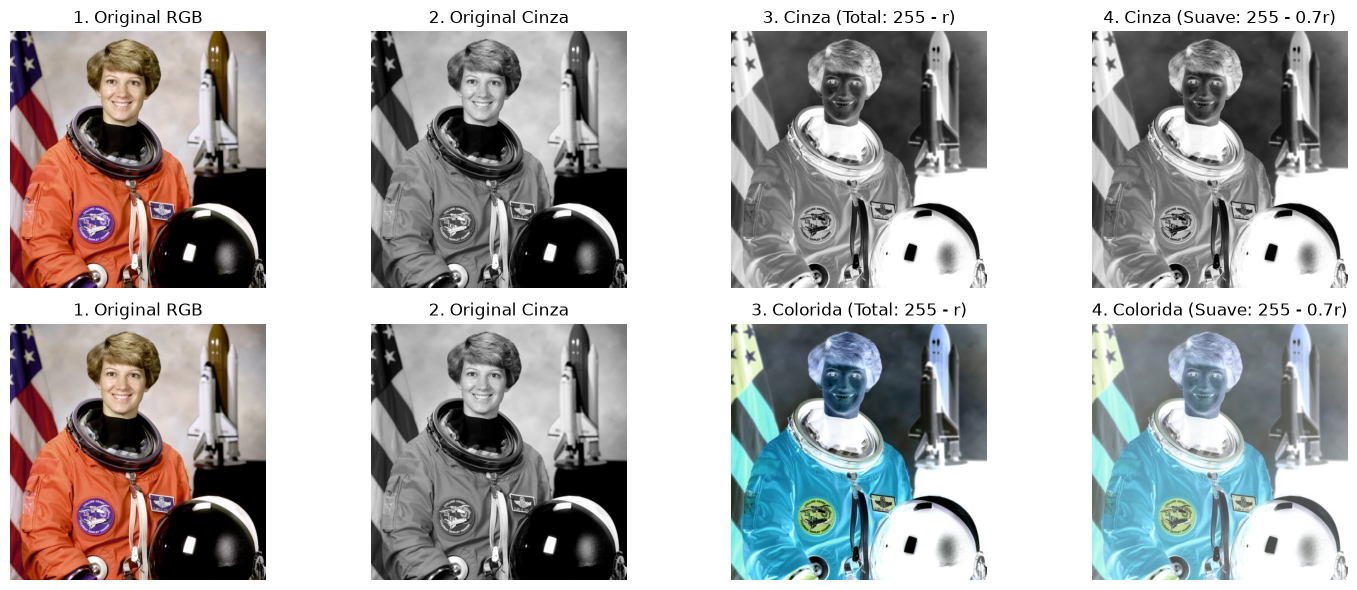

In [2]:
# Variação 1: Inversão total (s = 255 - r)
cinza_v1 = 255 - img_cinza
rgb_v1 = 255 - img_rgb

# Variação 2: Inversão com ganho suave (s = 255 - 0.7*r)
cinza_v2 = np.clip(255 - 0.7 * img_cinza, 0, 255).astype(np.uint8)
rgb_v2 = np.clip(255 - 0.7 * img_rgb, 0, 255).astype(np.uint8)

exibir(cinza_v1, cinza_v2, rgb_v1, rgb_v2, "Total: 255 - r", "Suave: 255 - 0.7r")


### b) Alongamento de Contraste (Contrast Stretching)
**Fórmula:** $s = \frac{r - r_{min}}{r_{max} - r_{min}} \times 255$


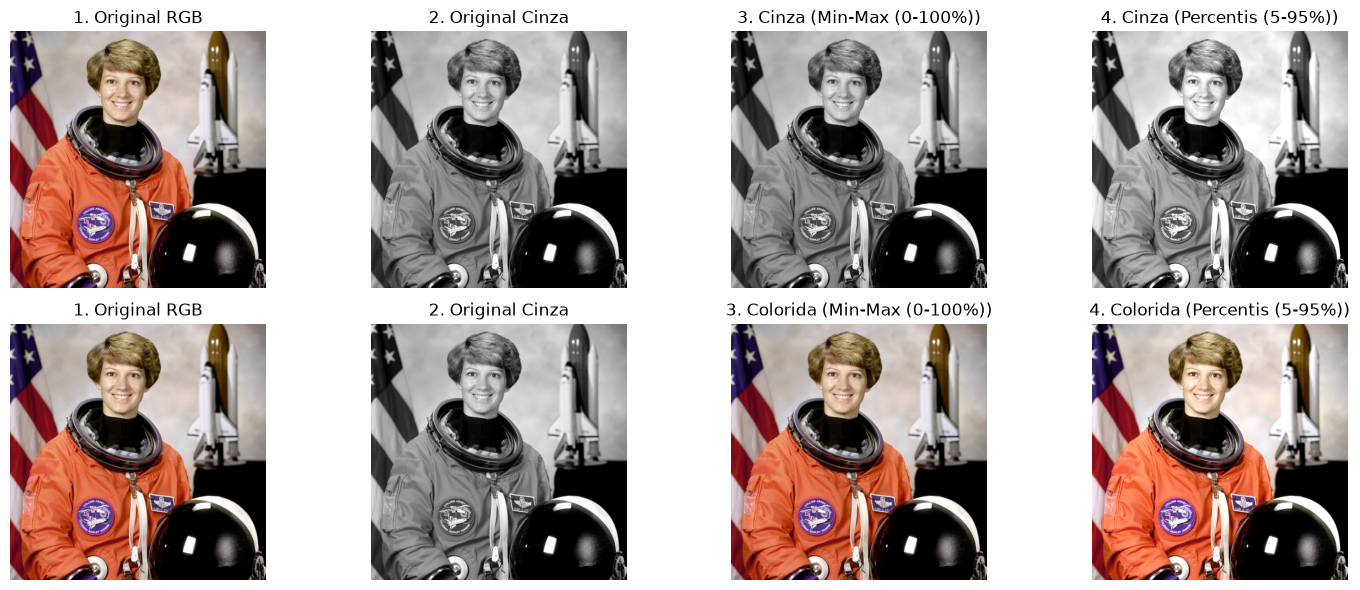

In [3]:
def stretch(img, p_min=0, p_max=100):
    rmin, rmax = np.percentile(img, p_min), np.percentile(img, p_max)
    return np.clip(((img - rmin) / (rmax - rmin)) * 255, 0, 255).astype(np.uint8)

# Variação 1: Min-Max (0% a 100%) | Variação 2: Percentis robustos (5% a 95%)
cinza_v1, rgb_v1 = stretch(img_cinza, 0, 100), stretch(img_rgb, 0, 100)
cinza_v2, rgb_v2 = stretch(img_cinza, 5, 95), stretch(img_rgb, 5, 95)

exibir(cinza_v1, cinza_v2, rgb_v1, rgb_v2, "Min-Max (0-100%)", "Percentis (5-95%)")


### c) Realce Linear
**Fórmula:** $s = \text{clip}(\alpha \cdot r + \beta, 0, 255)$


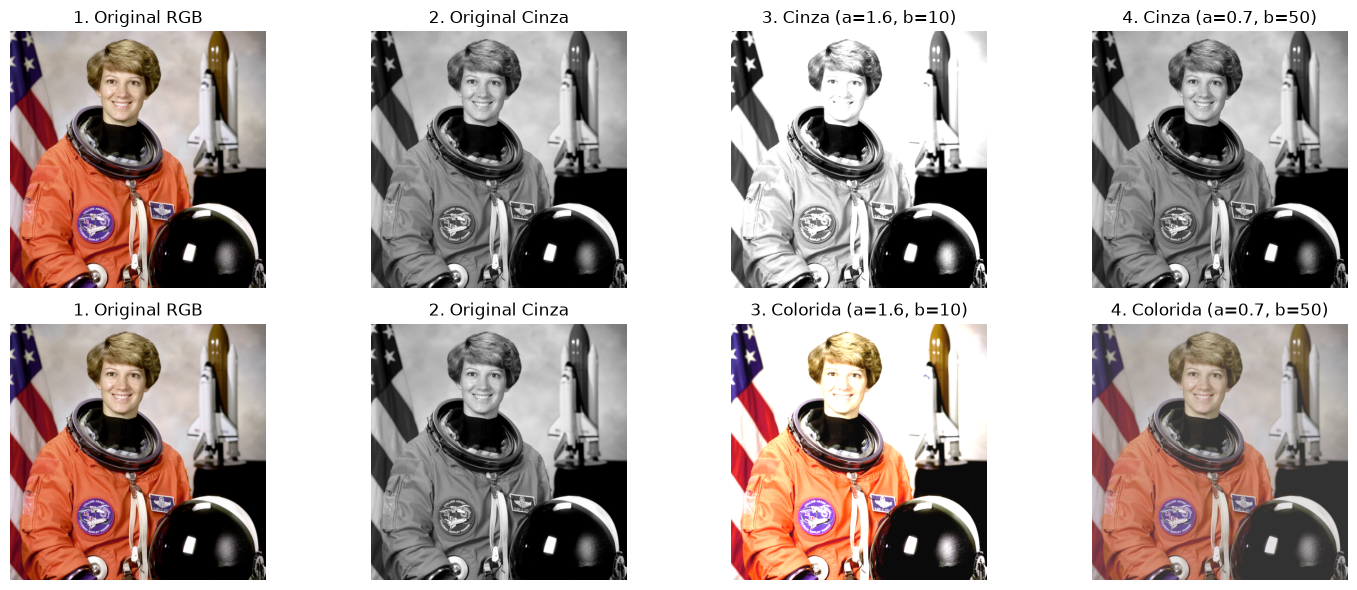

In [4]:
def linear(img, a, b):
    return np.clip(a * img.astype(np.float32) + b, 0, 255).astype(np.uint8)

# Variação 1: Alto contraste (a=1.6, b=10) | Variação 2: Baixo contraste e mais brilho (a=0.7, b=50)
cinza_v1, rgb_v1 = linear(img_cinza, 1.6, 10), linear(img_rgb, 1.6, 10)
cinza_v2, rgb_v2 = linear(img_cinza, 0.7, 50), linear(img_rgb, 0.7, 50)

exibir(cinza_v1, cinza_v2, rgb_v1, rgb_v2, "a=1.6, b=10", "a=0.7, b=50")


### d) Realce Logarítmico
**Fórmula:** $s = c \cdot \ln(1 + r)$


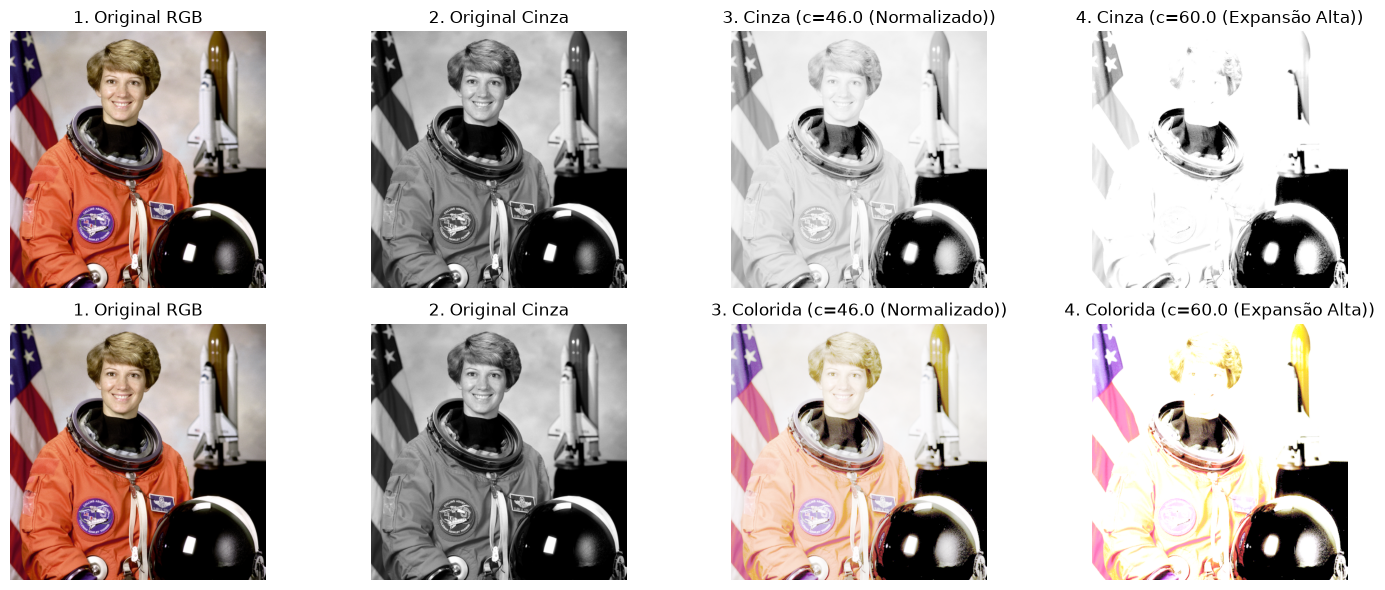

In [5]:
c_norm = 255.0 / np.log(256.0)

def log_transf(img, c):
    return np.clip(c * np.log(1.0 + img.astype(np.float32)), 0, 255).astype(np.uint8)

# Variação 1: c normalizado (~45.99) | Variação 2: c acentuado (60.0)
cinza_v1, rgb_v1 = log_transf(img_cinza, c_norm), log_transf(img_rgb, c_norm)
cinza_v2, rgb_v2 = log_transf(img_cinza, 60.0), log_transf(img_rgb, 60.0)

exibir(cinza_v1, cinza_v2, rgb_v1, rgb_v2, f"c={c_norm:.1f} (Normalizado)", "c=60.0 (Expansão Alta)")


### e) Realce Quadrático
**Fórmula:** $s = c \cdot r^2 = \frac{r^2}{255}$


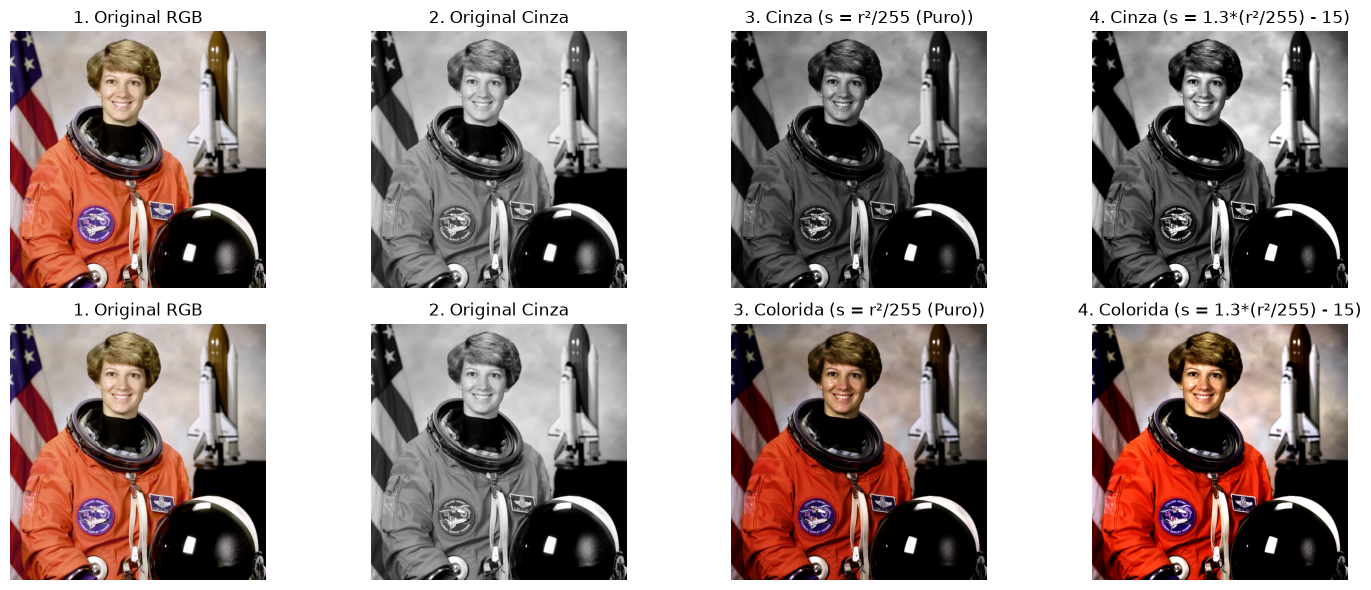

In [6]:
def quadratico(img, ganho=1.0, offset=0):
    return np.clip(ganho * ((img.astype(np.float32) ** 2) / 255.0) + offset, 0, 255).astype(np.uint8)

# Variação 1: s = r²/255 | Variação 2: s = 1.3*(r²/255) - 15 (Acentuado)
cinza_v1, rgb_v1 = quadratico(img_cinza, 1.0, 0), quadratico(img_rgb, 1.0, 0)
cinza_v2, rgb_v2 = quadratico(img_cinza, 1.3, -15), quadratico(img_rgb, 1.3, -15)

exibir(cinza_v1, cinza_v2, rgb_v1, rgb_v2, "s = r²/255 (Puro)", "s = 1.3*(r²/255) - 15")


### f) Realce por Raiz Quadrada
**Fórmula:** $s = 255 \cdot \sqrt{\frac{r}{255}}$


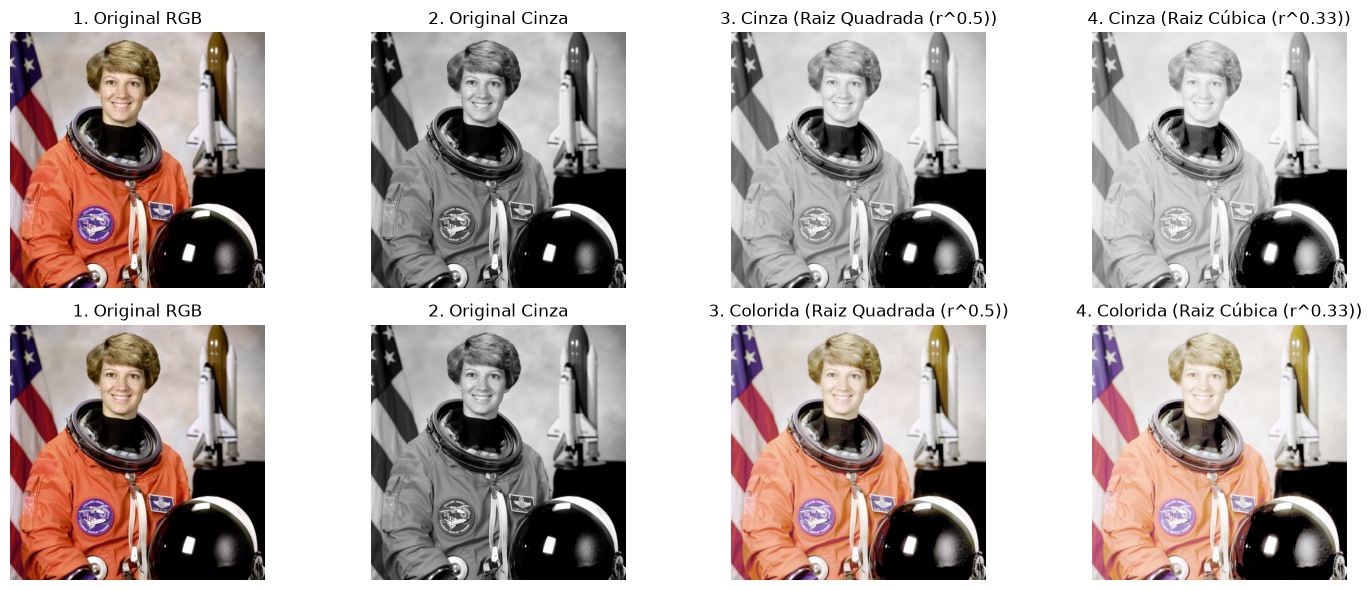

In [7]:
def raiz(img, exp):
    return np.clip(255.0 * ((img.astype(np.float32) / 255.0) ** exp), 0, 255).astype(np.uint8)

# Variação 1: Raiz quadrada (exp=0.5) | Variação 2: Raiz cúbica (exp=1/3)
cinza_v1, rgb_v1 = raiz(img_cinza, 0.5), raiz(img_rgb, 0.5)
cinza_v2, rgb_v2 = raiz(img_cinza, 1.0/3.0), raiz(img_rgb, 1.0/3.0)

exibir(cinza_v1, cinza_v2, rgb_v1, rgb_v2, "Raiz Quadrada (r^0.5)", "Raiz Cúbica (r^0.33)")


### g) Correção Gama
**Fórmula:** $s = 255 \cdot \left(\frac{r}{255}\right)^\gamma$


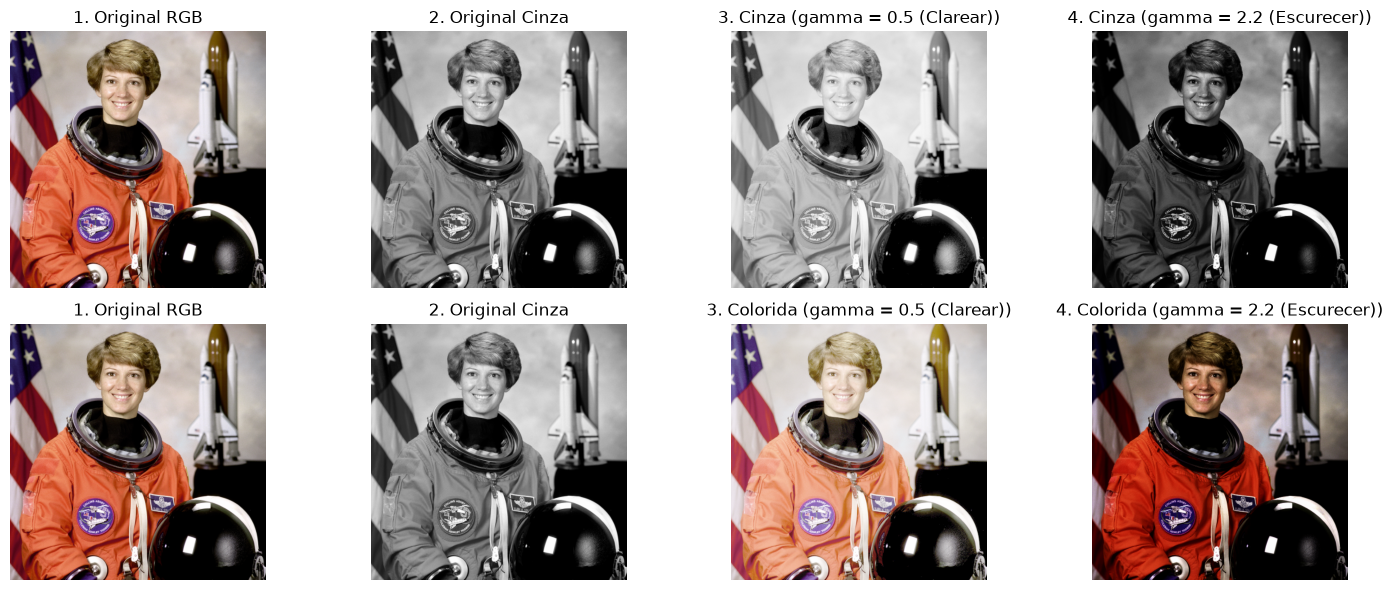

In [8]:
def gama(img, g):
    return np.clip(255.0 * ((img.astype(np.float32) / 255.0) ** g), 0, 255).astype(np.uint8)

# Variação 1: gamma = 0.5 (Clareamento) | Variação 2: gamma = 2.2 (Escurecimento)
cinza_v1, rgb_v1 = gama(img_cinza, 0.5), gama(img_rgb, 0.5)
cinza_v2, rgb_v2 = gama(img_cinza, 2.2), gama(img_rgb, 2.2)

exibir(cinza_v1, cinza_v2, rgb_v1, rgb_v2, "gamma = 0.5 (Clarear)", "gamma = 2.2 (Escurecer)")
